# 第8章　LightGBM

## 8.4　PythonでLightGBM

### コード8.1

In [ ]:
!pip install japanize-matplotlib

1. データの準備中...
特徴量の数: 30種類
サンプル数: 569件
ターゲットのクラス: [np.str_('malignant'), np.str_('benign')]

2. データ前処理(スキップ)...

3. データの分割中...
学習データ: 364件
検証データ: 91件
テストデータ: 114件

4. LightGBMモデルの学習開始...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 228, number of negative: 136
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3648
[LightGBM] [Info] Number of data points in the train set: 364, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further

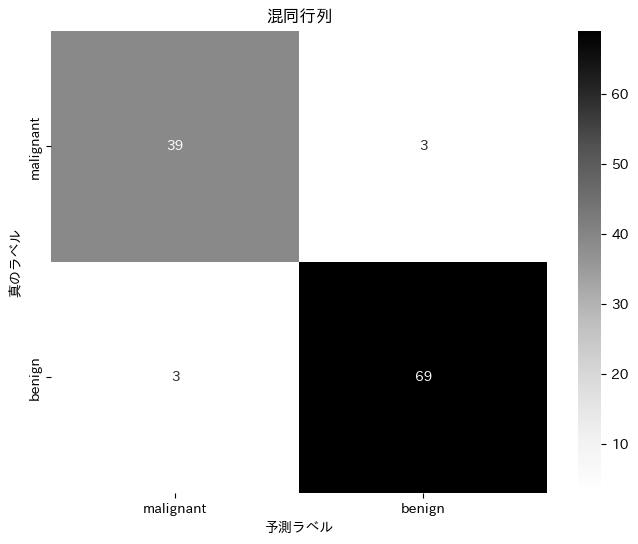


6. 特徴量の重要度グラフの描画...


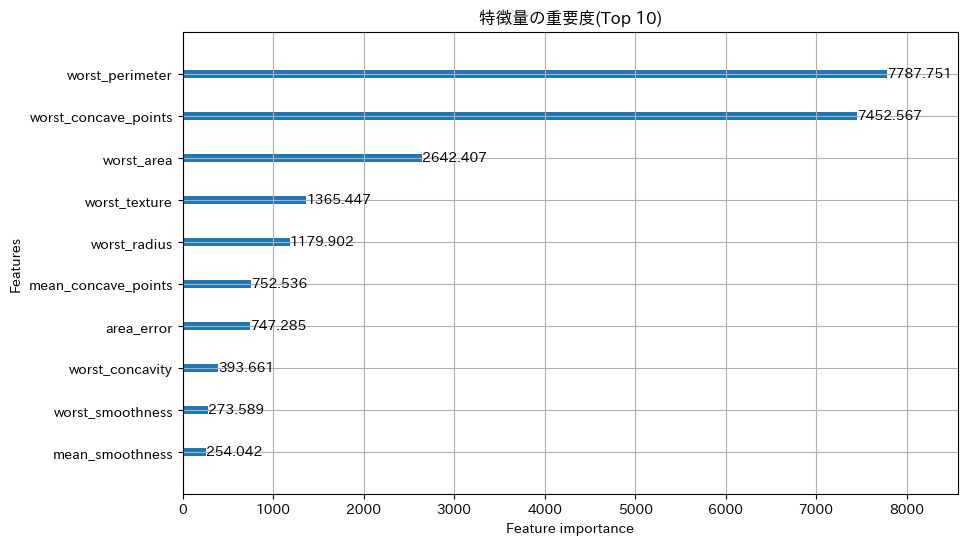

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. 日本語フォントの設定---
import japanize_matplotlib


# --- 1. データの準備---
print("1. データの準備中...")

cancer_data = load_breast_cancer()

X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target

print(f"特徴量の数: {X.shape[1]}種類")
print(f"サンプル数: {X.shape[0]}件")
print(f"ターゲットのクラス: {list(cancer_data.target_names)}")


# --- 2. データ前処理---
print("\n2. データ前処理(スキップ)...")


# --- 3. データの分割---
print("\n3. データの分割中...")

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
	X_train_valid, y_train_valid, test_size=0.2, random_state=42, stratify=y_train_valid
)

print(f"学習データ: {X_train.shape[0]}件")
print(f"検証データ: {X_valid.shape[0]}件")
print(f"テストデータ: {X_test.shape[0]}件")


# --- 4. LightGBMモデルの学習---
print("\n4. LightGBMモデルの学習開始...")

lgbm = lgb.LGBMClassifier(
	objective='binary',
	metric='binary_logloss',
	n_estimators=1000,
	learning_rate=0.01,
	random_state=42,
	n_jobs=-1,
	# --- ビン離散化パラメータ---
	max_bin=255, # 特徴量を離散化するビン数の上限(デフォルト: 255)
	min_data_in_bin=3, # 各ビンに必要な最小データ数(min_bin_size の別名,デフォルト: 3)
	# --- 葉の分割制約---
	min_child_samples=40, # 葉の最小データ数(デフォルト: 20)
	min_child_weight=0.002 # 葉の最小重み合計(デフォルト: 1e_3)
)

lgbm.fit(
	X_train,
	y_train,
	eval_set=[(X_valid, y_valid)],
	eval_metric='binary_logloss',
	callbacks=[
		lgb.early_stopping(stopping_rounds=100, verbose=True),
		lgb.log_evaluation(period=200)
	]
)

print("学習完了。")

# --- 5. モデルの評価---
print("\n5. モデルの評価中...")

y_pred = lgbm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nテストデータの正解率(Accuracy): {accuracy:.4f}")

print("\n分類レポート:")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

# --- 混同行列の表示---
print("\n混同行列の描画...")

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=cancer_data.target_names, columns=cancer_data.target_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greys')
plt.title('混同行列')
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.show()


# --- 6. 特徴量の重要度の可視化---
print("\n6. 特徴量の重要度グラフの描画...")

fig, ax = plt.subplots(figsize=(10, 6))
lgb.plot_importance(
	lgbm,
	max_num_features=10,
	ax=ax,
	title='特徴量の重要度(Top 10)',
	importance_type='gain'
)
plt.show()